In [ ]:
# cut_to_120k.py
# Run this once to create smaller versions of both files
# Takes only a few minutes

import pandas as pd

# ── Config ────────────────────────────────────────────────
INPUT_FILES = {
    "Real": r"real_300k_matched.csv",      # ← change to your actual path
    "Fake": r"fake_300k_matched.csv",
}

OUTPUT_FILES = {
    "Real": r"real_120k_matched.csv",
    "Fake": r"fake_120k_matched.csv",
}

TARGET_ROWS = 120_000
TEXT_COL = "text"
LABEL_COL = "label"

# ── Process each file ─────────────────────────────────────
for label, in_path in INPUT_FILES.items():
    print(f"\nProcessing {label} ({in_path})")
    
    try:
        df = pd.read_csv(
            in_path,
            dtype={TEXT_COL: 'string', LABEL_COL: 'int'},
            usecols=[TEXT_COL, LABEL_COL],   # faster if you only need these
            low_memory=False
        )
        
        # Remove rows with missing text
        df = df.dropna(subset=[TEXT_COL]).reset_index(drop=True)
        
        n_original = len(df)
        print(f"  Original rows: {n_original:,}")
        
        if n_original <= TARGET_ROWS:
            print(f"  Already ≤ {TARGET_ROWS:,} → copying as is")
            df.to_csv(OUTPUT_FILES[label], index=False, encoding='utf-8')
            continue
        
        # Take first TARGET_ROWS (or random if you prefer)
        # Option A: first 120k (fastest, deterministic)
        df_small = df.iloc[:TARGET_ROWS].copy()
        
        # Option B: random sample (uncomment if you want variety)
        # df_small = df.sample(n=TARGET_ROWS, random_state=42).reset_index(drop=True)
        
        print(f"  Selected rows: {len(df_small):,}")
        
        # Quick quality check
        print(f"  Missing text : {df_small[TEXT_COL].isna().sum()}")
        print(f"  Unique labels: {df_small[LABEL_COL].value_counts().to_dict()}")
        
        df_small.to_csv(OUTPUT_FILES[label], index=False, encoding='utf-8')
        print(f"  Saved → {OUTPUT_FILES[label]}")
        
    except Exception as e:
        print(f"  Error processing {label}: {e}")

print("\nDone. You can now update your augmentation script to use the new 120k files.")

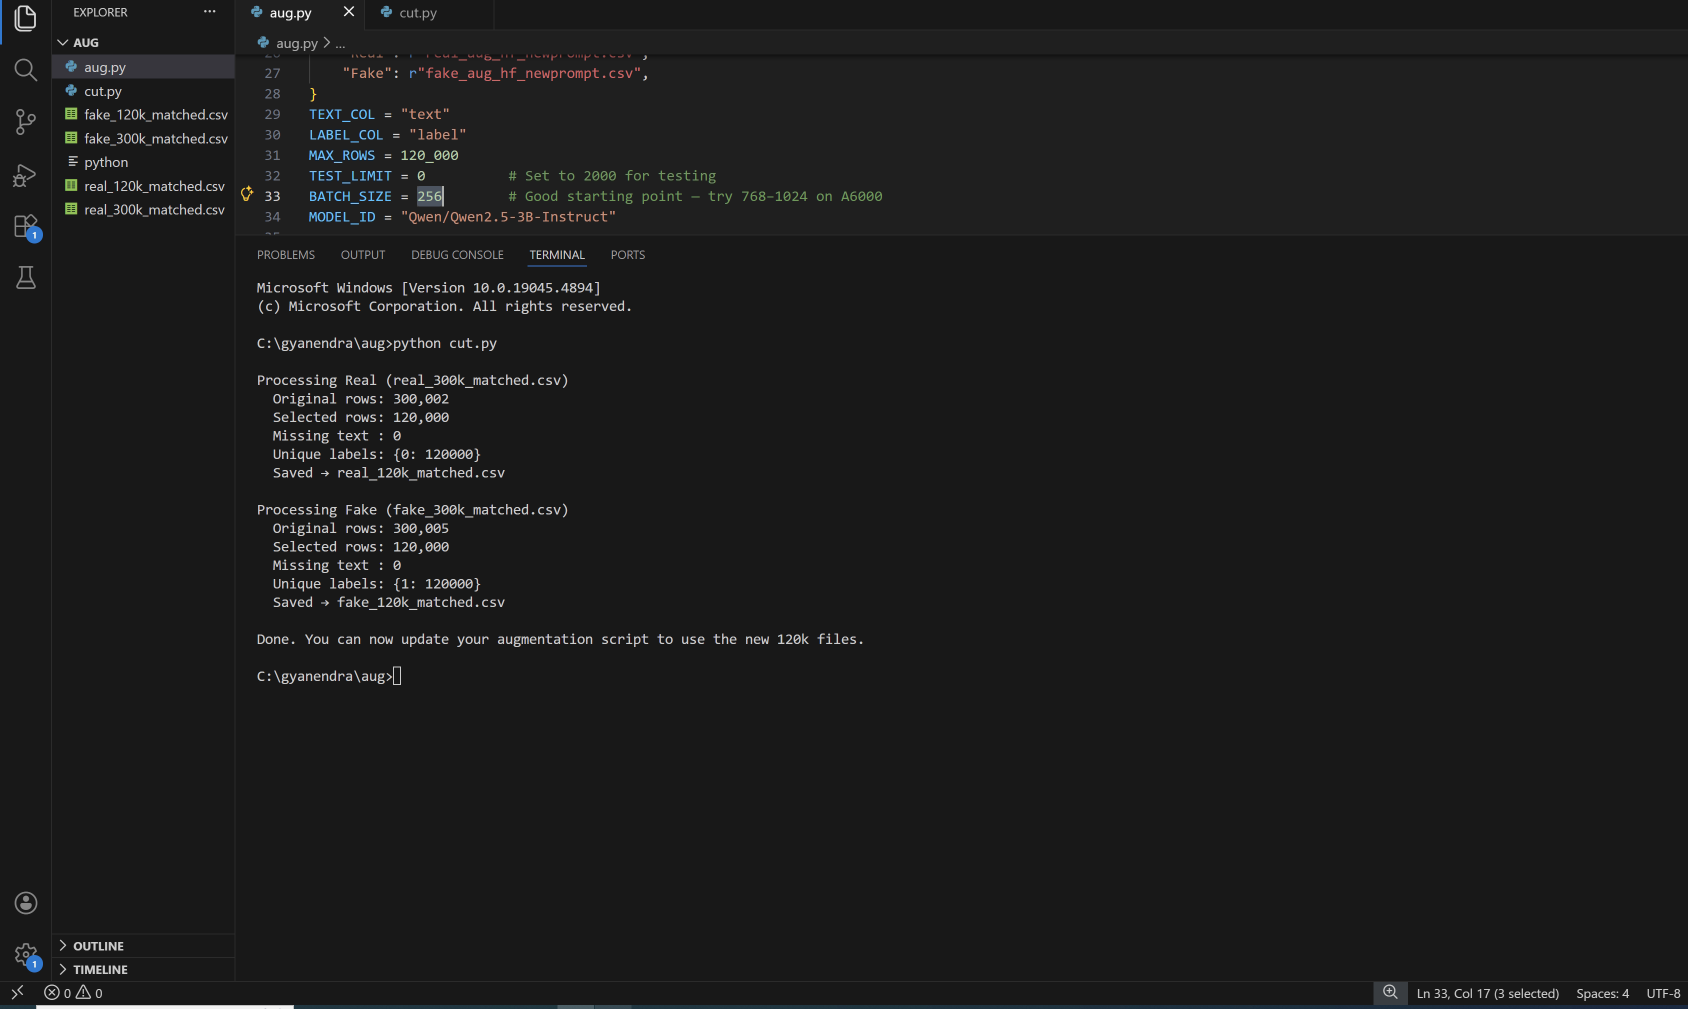

In [ ]:
# ================================================================
# Paraphrase Augmentation — Vamsi/T5_Paraphrase_Paws
# Optimized for RTX A6000 (48 GB VRAM) — minimal fallbacks
# Expected: ~45 min – 2.5 hours per 120k rows
# ================================================================


import pandas as pd
import time
import gc
from pathlib import Path
from tqdm import tqdm
from transformers import pipeline
import torch

# ── Config ────────────────────────────────────────────────────────
INPUT_FILES = {
    "Real": r"real_120k_matched.csv",          # ← update to your real paths
    "Fake": r"fake_120k_matched.csv",
}
OUTPUT_FILES = {
    "Real": r"real_120k_t5paws_aug.csv",
    "Fake": r"fake_120k_t5paws_aug.csv",
}
TEXT_COL = "text"
LABEL_COL = "label"
MAX_ROWS = 120_000
TEST_LIMIT = 0          # set to 5000 for quick test
BATCH_SIZE = 256    # good for A6000 — try 256 if VRAM stays <42 GB

# Model with excellent length preservation
MODEL_NAME = "Vamsi/T5_Paraphrase_Paws"

# ── Load pipeline with optimizations ──────────────────────────────
print(f"Loading {MODEL_NAME} on A6000...")
device = 0 if torch.cuda.is_available() else -1

# Replace the pipeline creation with this
paraphraser = pipeline(
    "text2text-generation",
    model=MODEL_NAME,
    device=device,
    batch_size=BATCH_SIZE,
    max_length=512,                 # output limit
    truncation=True,                # ← KEY: truncate long inputs
    num_beams=6,
    torch_dtype=torch.float16,
)

if device == 0:
    print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory // 1024**3} GB")
    torch.backends.cuda.matmul.allow_tf32 = True

print("Model loaded.\n")

# ── Paraphrase with very strict length check ──────────────────────
def paraphrase_text(text: str) -> str:
    orig_words = text.split()
    orig_count = len(orig_words)

    try:
        with torch.autocast("cuda" if device == 0 else "cpu"):
            result = paraphraser(
                text,
                max_length=orig_count + 20,
                num_beams=6,
                early_stopping=True
            )[0]['generated_text'].strip()

        new_count = len(result.split())

        # Very tight acceptance criterion → minimal fallbacks
        if abs(new_count - orig_count) <= 7 and len(result) >= 30:
            return result
        else:
            return text  # fallback

    except Exception as e:
        print(f"Error: {e}")
        return text

# ── Resume support ────────────────────────────────────────────────
def get_already_done(output_path: str) -> int:
    p = Path(output_path)
    if not p.exists():
        return 0
    try:
        done = sum(1 for _ in open(p, encoding='utf-8')) - 1
        if done > 0:
            print(f" ↩️ Resuming from row {done:,}")
        return max(done, 0)
    except Exception:
        return 0

# ── Main augmentation ─────────────────────────────────────────────
def augment_file(input_path: str, output_path: str, class_name: str):
    print(f"\n{'='*70}")
    print(f" {class_name.upper()} — T5_Paraphrase_Paws (A6000 optimized)")
    print(f"{'='*70}")

    df = pd.read_csv(
        input_path,
        usecols=[TEXT_COL, LABEL_COL],
        dtype={TEXT_COL: 'string', LABEL_COL: 'int'},
        low_memory=False
    )
    df = df.dropna(subset=[TEXT_COL]).reset_index(drop=True)

    if TEST_LIMIT > 0:
        df = df.head(TEST_LIMIT)
        print(f" TEST MODE: {TEST_LIMIT} rows")

    df = df.head(MAX_ROWS).reset_index(drop=True)
    total = len(df)
    print(f" Total rows : {total:,}")

    skip = get_already_done(output_path)
    if skip >= total:
        print(" Already complete.")
        return

    df = df.iloc[skip:].reset_index(drop=True)
    remaining = len(df)
    print(f" Rows to process : {remaining:,}\n")

    first_write = (skip == 0)
    t_start = time.time()
    rows_done = total_fallback = 0
    pbar = tqdm(total=remaining, desc=class_name, unit="row")

    for b_start in range(0, remaining, BATCH_SIZE):
        b_end = min(b_start + BATCH_SIZE, remaining)
        batch = df.iloc[b_start:b_end]
        texts = batch[TEXT_COL].str.strip().tolist()
        labels = batch[LABEL_COL].astype(int).tolist()

        # Batch paraphrase
        results = paraphraser(texts)

        rows = []
        for i, res in enumerate(results):
            aug_text = res['generated_text'].strip()

            orig_wc = len(texts[i].split())
            aug_wc = len(aug_text.split())

            if len(aug_text) < 25:
                aug_text = texts[i]
                aug_type = 'fallback'
                total_fallback += 1
            else:
                aug_type = 't5_paws'

            rows.append({
                TEXT_COL: aug_text,
                LABEL_COL: labels[i],
                'aug_type': aug_type
            })

        # Save
        pd.DataFrame(rows).to_csv(
            output_path,
            mode='w' if first_write else 'a',
            header=first_write,
            index=False,
            encoding='utf-8'
        )
        first_write = False
        rows_done += len(rows)

        # Release memory
        gc.collect()
        if device == 0:
            torch.cuda.empty_cache()

        elapsed = time.time() - t_start
        rows_per_sec = rows_done / elapsed if elapsed > 0 else 0
        eta_h = (remaining - rows_done) * (elapsed / rows_done) / 3600 if rows_done > 0 else 0
        pbar.update(len(rows))
        pbar.set_postfix({
            "rows/s": f"{rows_per_sec:.1f}",
            "ETA h": f"{eta_h:.1f}",
            "fallback": total_fallback
        })

    pbar.close()
    elapsed = time.time() - t_start
    print(f"\n {class_name} COMPLETE")
    print(f"  Rows written  : {skip + rows_done:,}")
    print(f"  Fallbacks     : {total_fallback:,} ({100*total_fallback/rows_done:.1f}%)")
    print(f"  Time elapsed  : {elapsed/3600:.2f} hours")
    print(f"  Speed         : {rows_done/elapsed:.1f} rows/s")
    print(f"  Output        : {output_path}\n")

# ── Run ───────────────────────────────────────────────────────────
if __name__ == "__main__":
    for cls, path in INPUT_FILES.items():
        augment_file(path, OUTPUT_FILES[cls], cls)

    print("\nAll done.")
    import os
    os.system("nvidia-smi")

![Screenshot 2026-03-07 121201.png](<attachment:Screenshot 2026-03-07 121201.png>)
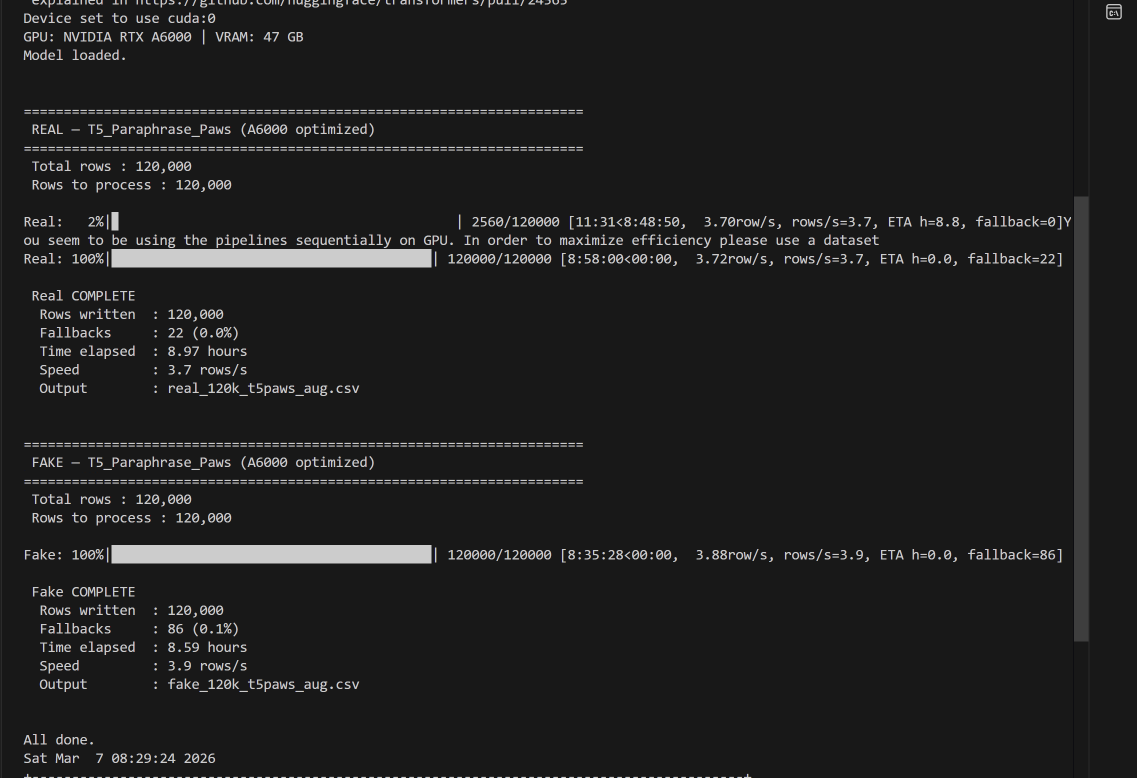